### Importing Libraries

In [3]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

GPU Usage?

In [4]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU!")

    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)

    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("TensorFlow is using the CPU.")

TensorFlow is using the GPU!
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'compute_capability': (8, 6)}


In [5]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\H5\E5_ImprovedCNN_P1I1A3M2T2.h5"


if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print("\nModel loaded successfully")
else:
    print("\nModel not found! Check the path.")


Model not found! Check the path.


In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Pneumonia Data___Set


In [7]:
labels = ['PNEUMONIA','NORMAL']
img_resize = 150

def get_data(dir):
    data = []
    for label in labels:
        path = os.path.join(dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                if img.endswith('jpeg'):
                    img_arr = cv2.imread(os.path.join(path,img), cv2.IMREAD_GRAYSCALE)
                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data,dtype= 'object')


In [8]:
train = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\train")
val   = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\val")
test  = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\test")

In [9]:
def count_images(dataset, name):

    pneumonia = 0
    normal = 0

    for i in dataset:
        if i[1] == 0:
            pneumonia += 1
        else:
            normal += 1

    total = pneumonia + normal

    print(f"\n{name} DATASET:")
    print("Total images:", total)
    print("PNEUMONIA images:", pneumonia)
    print("NORMAL images:", normal)


count_images(train, "TRAIN")
count_images(val, "VALIDATION")
count_images(test, "TEST")


TRAIN DATASET:
Total images: 5170
PNEUMONIA images: 3852
NORMAL images: 1318

VALIDATION DATASET:
Total images: 62
PNEUMONIA images: 31
NORMAL images: 31

TEST DATASET:
Total images: 624
PNEUMONIA images: 390
NORMAL images: 234


## Data Visualization && Preprocessing

<Axes: xlabel='count'>

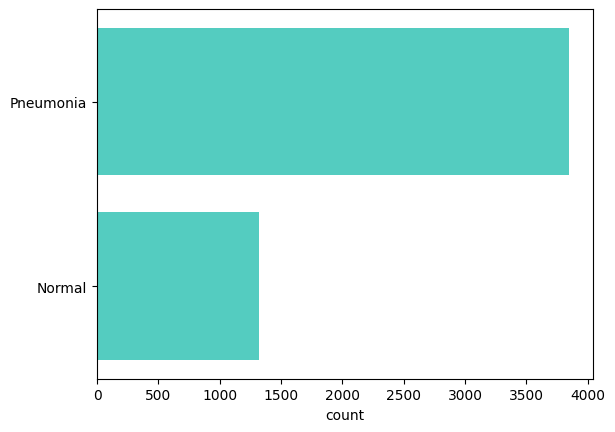

In [10]:
l = []
for i in train:
    if (i[1] == 0):
        l.append('Pneumonia')
    else:
        l.append('Normal')

sns.countplot(y=l, color='#40E0D0')

Text(0.5, 1.0, 'NORMAL')

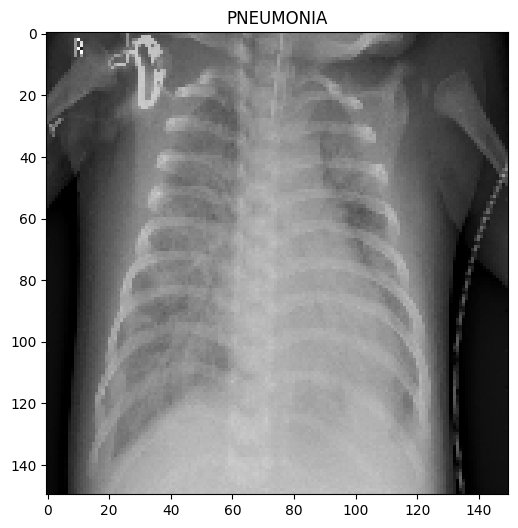

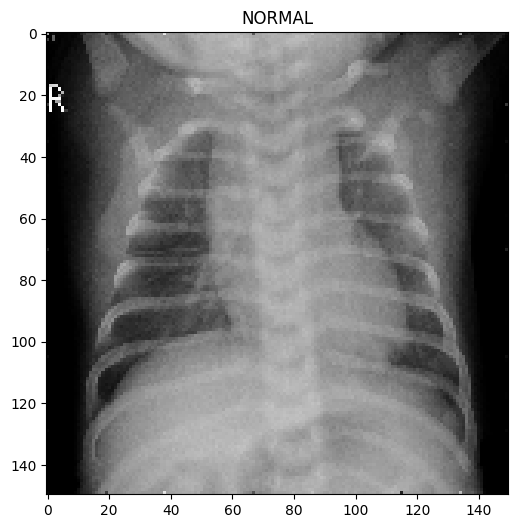

In [11]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [12]:
x_train = []
y_train = []
for feat, label in train:
    x_train.append(feat)
    y_train.append(label)


x_val = []
y_val = []
for feat,label in val:
    x_val.append(feat)
    y_val.append(label)


x_test = []
y_test = []
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)


## Normalizing       data ........

In [13]:
#Normalizing.... data
# for reducing computation....
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

# suitable for CNN

In [14]:
x_train = x_train.reshape(-1,img_resize, img_resize,1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1,img_resize,img_resize,1)
y_val = np.array(y_val)


x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

# data augmentation

In [15]:
data__gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

data__gen.fit(x_train)

## Train........

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()


# Block 1
model.add(Conv2D(
    32,
    (3, 3),
    padding='same',
    activation='relu',
    input_shape=(150, 150, 1)
))

model.add(BatchNormalization())

model.add(MaxPool2D(
    pool_size=(2, 2)
))

model.add(Dropout(
    0.10
))


# Block 2
model.add(Conv2D(
    64,
    (3, 3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPool2D(
    pool_size=(2, 2)
))

model.add(Dropout(
    0.15
))


# Block 3
model.add(Conv2D(
    128,
    (3, 3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPool2D(
    pool_size=(2, 2)
))

model.add(Dropout(
    0.20
))


# Block 4
model.add(Conv2D(
    256,
    (3, 3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPool2D(
    pool_size=(2, 2)
))

model.add(Dropout(
    0.25
))


# Flatten Layer
model.add(Flatten())


# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(
    0.30
))


# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))


# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 75, 75, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 75, 75, 64)       2

In [17]:
# learning_rate_reduction = ReduceLROnPlateau(
#     monitor='val_accuracy',
#     patience=2,
#     verbose=1,
#     factor=0.3,
#     min_lr=0.000001
# )


# is about class weights, not LR scheduling.........

In [18]:
# checkpoint = ModelCheckpoint(
#     MODEL_PATH,
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

# # No checkpoint

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 0.6710799584631361, 1: 1.9613050075872533}


In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    data__gen.flow(x_train, y_train, batch_size=16),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/30
324/324 [==============================] - 33s 74ms/step - loss: 0.7194 - accuracy: 0.8489 - val_loss: 49.4384 - val_accuracy: 0.5000
Epoch 2/30
324/324 [==============================] - 24s 75ms/step - loss: 0.2442 - accuracy: 0.9044 - val_loss: 2.7599 - val_accuracy: 0.7258
Epoch 3/30
324/324 [==============================] - 25s 76ms/step - loss: 0.2435 - accuracy: 0.9012 - val_loss: 2.9378 - val_accuracy: 0.5323
Epoch 4/30
324/324 [==============================] - 25s 75ms/step - loss: 0.2466 - accuracy: 0.9062 - val_loss: 0.3745 - val_accuracy: 0.8226
Epoch 5/30
324/324 [==============================] - 23s 71ms/step - loss: 0.1916 - accuracy: 0.9215 - val_loss: 0.8704 - val_accuracy: 0.7581
Epoch 6/30
324/324 [==============================] - 25s 76ms/step - loss: 0.2129 - accuracy: 0.9081 - val_loss: 0.5521 - val_accuracy: 0.7581
Epoch 7/30
324/324 [==============================] - 24s 74ms/step - loss: 0.2005 - accuracy: 0.9257 - val_loss: 1.4180 - val_accuracy

In [21]:
model.save(MODEL_PATH)
print("Model saved successfully")

Model saved successfully


In [22]:
model.evaluate(x_test,y_test)

20/20 [==============================] - 1s 22ms/step - loss: 0.3548 - accuracy: 0.8718


[0.3548148274421692, 0.8717948794364929]

In [23]:
loss, acc = model.evaluate(x_test, y_test, batch_size=4, verbose=1)

print(f"Loss of the model is {loss}")
print(f"Accuracy of the model is {acc*100:.2f} %")

156/156 [==============================] - 3s 13ms/step - loss: 0.3548 - accuracy: 0.8718
Loss of the model is 0.35481488704681396
Accuracy of the model is 87.18 %


# Analyse Model Performance

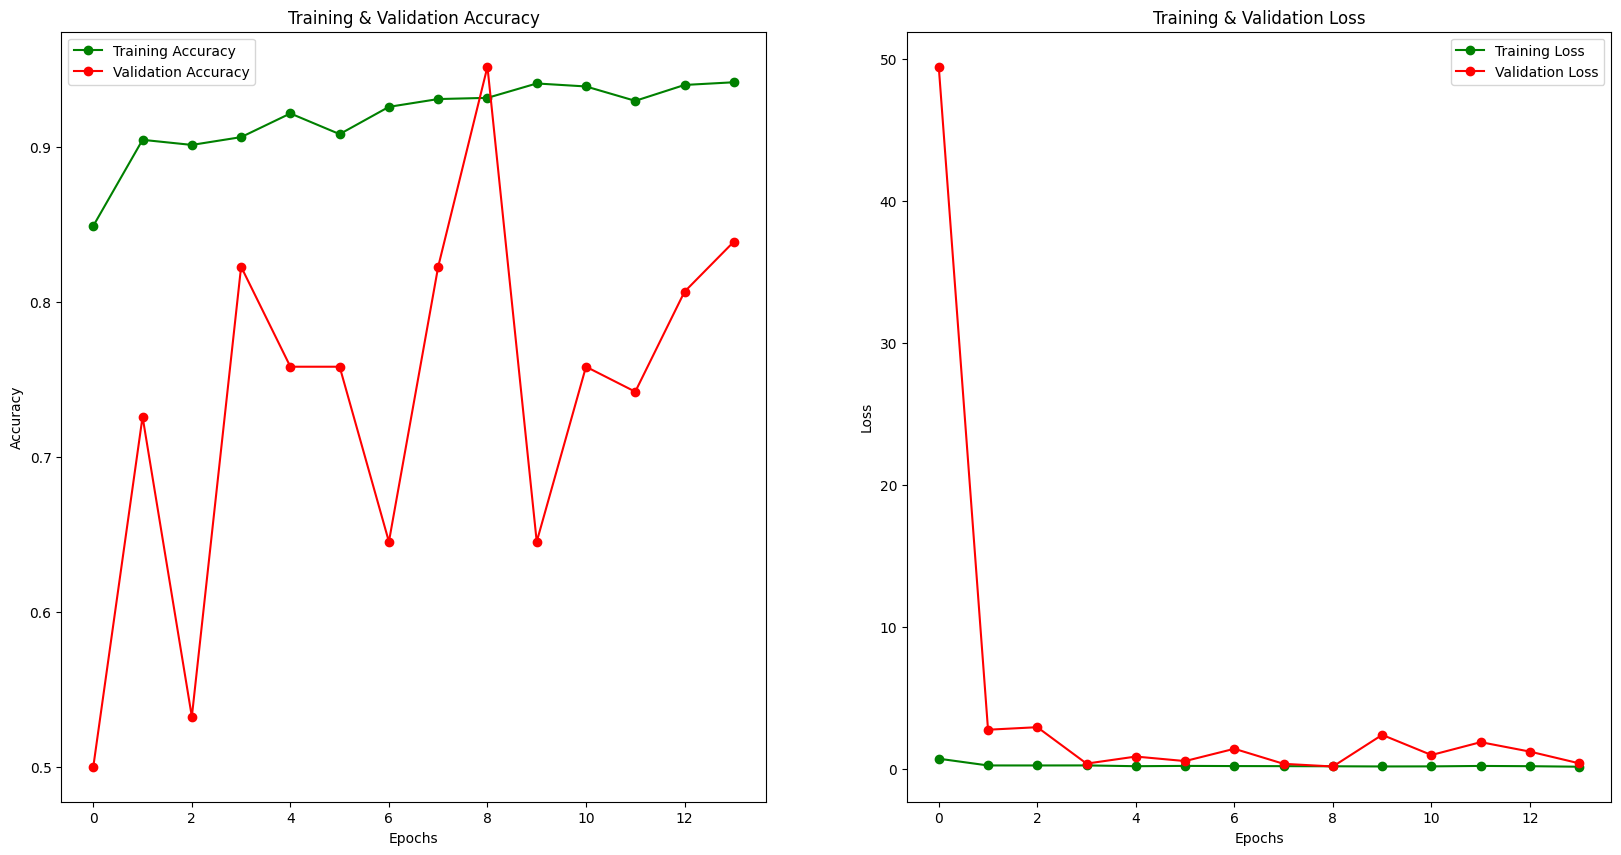

In [24]:
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

In [25]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 [==============================] - 1s 22ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [26]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))


                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.84      0.98      0.90       390
   Normal (Class 1)       0.95      0.70      0.80       234

           accuracy                           0.87       624
          macro avg       0.90      0.84      0.85       624
       weighted avg       0.88      0.87      0.87       624



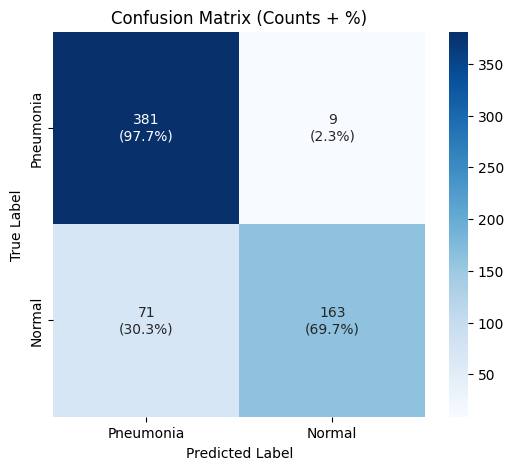

In [27]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]



import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

# Label
labels = ['Pneumonia', 'Normal']

#percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"


# Plottin confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Counts + %)")
plt.show()

#Some correctly Predicted Classes---->>>

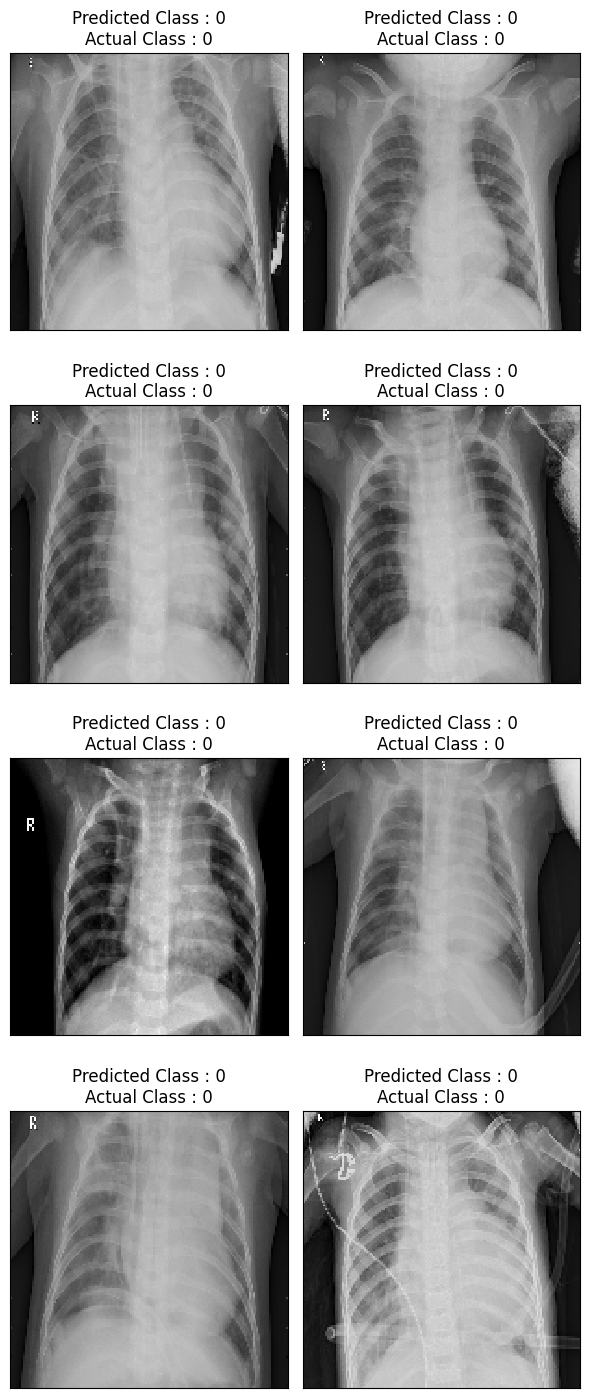

In [28]:

i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(img_resize,img_resize), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

#Some incorrectly Predicted Classes____>>>

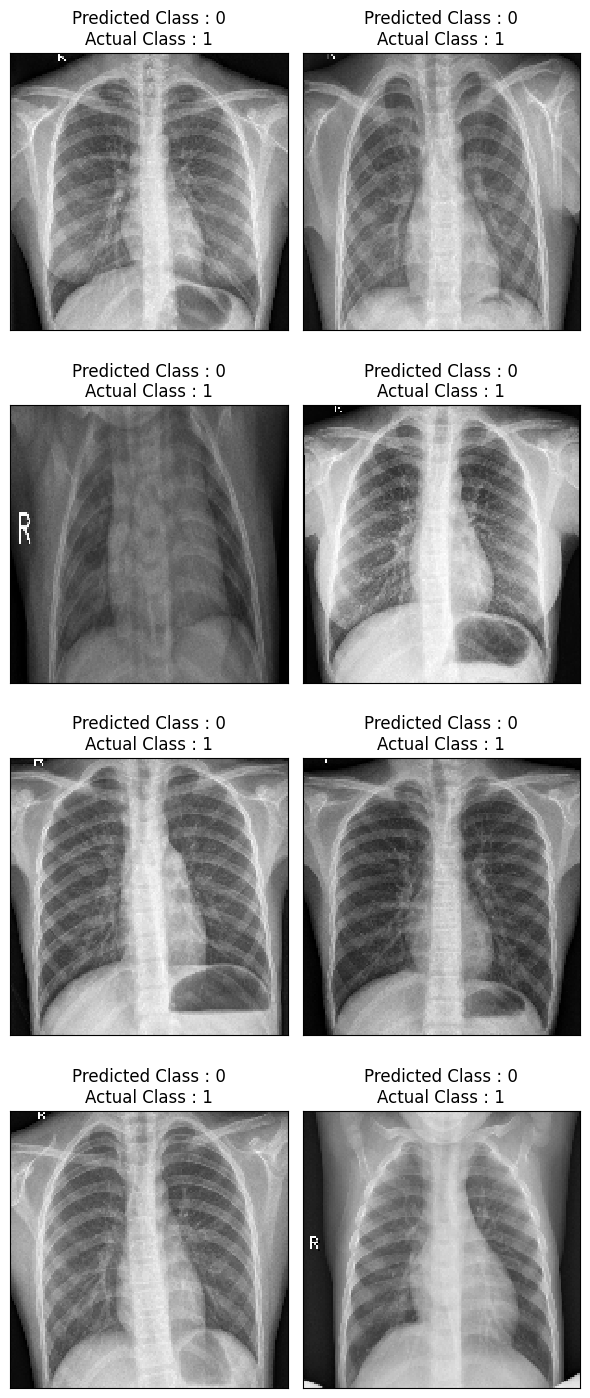

In [29]:
# //for incorrect predicted classes hum normal ko Penumonia dekha
# sakte hai but not vice versa........

i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(img_resize,img_resize), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1